# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Krishma-adhikari/flyrank-projects/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!git clone https://github.com/Krishma-adhikari/flyrank-projects.git

fatal: destination path 'flyrank-projects' already exists and is not an empty directory.


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('flyrank-projects/data/raw/content_refresh_anonymized.csv')

In [ ]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [126]:
df.shape

(30000, 44)

In [127]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=30000, step=1)

In [ ]:
df.isnull().sum()

,0
content_id,0
client_id,0
search_volume,2468
competition,2468
competition_level,2610
cpc,2468
content_type,0
main_intent,2374
word_count,7699
char_count,7699


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


In [ ]:
df.shape

(30000, 44)

In [4]:
df = df.drop(columns = ['content_id','client_id','age_tier_order'], axis = 1)

In [ ]:
# EDA

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

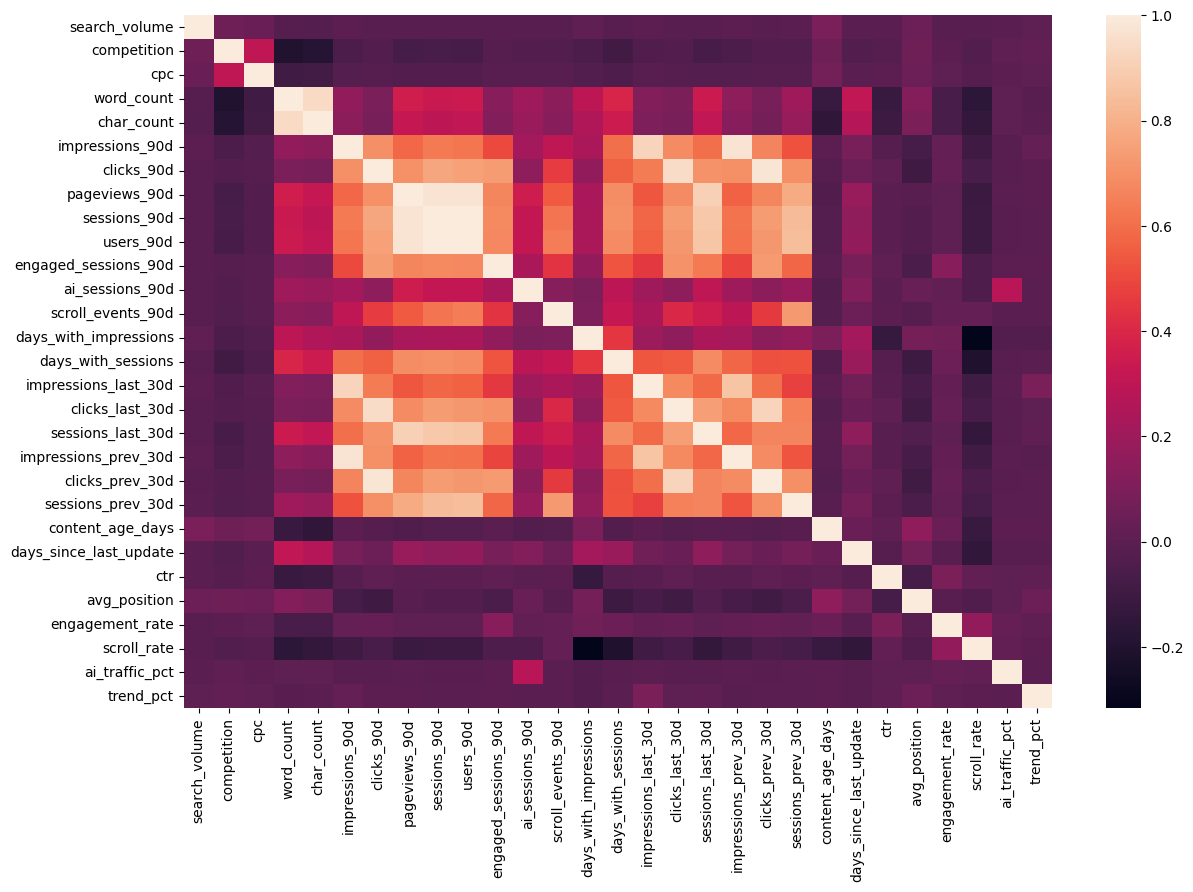

In [95]:
corre = df.corr(numeric_only = True)
plt.figure(figsize=(14,9))
sns.heatmap(corre)
plt.show()

In [5]:
num = df.select_dtypes(include = 'number').columns

In [6]:
cat = df.select_dtypes(include = 'object').columns

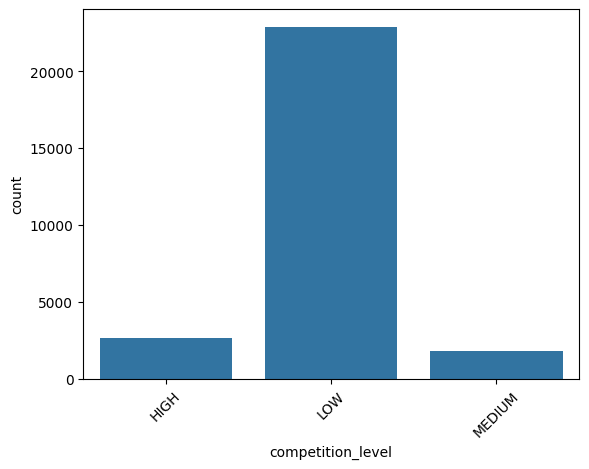

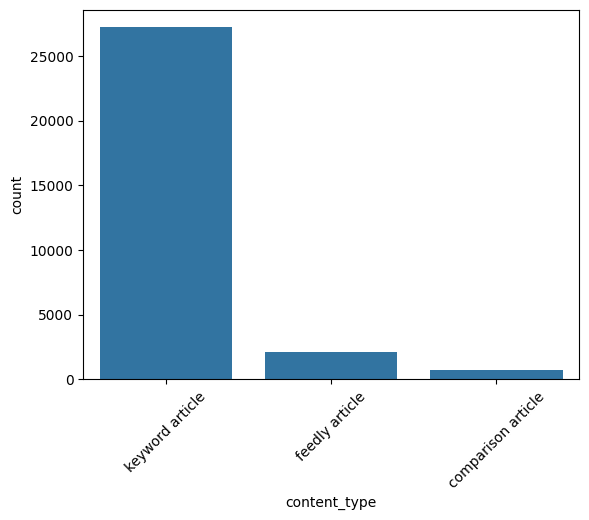

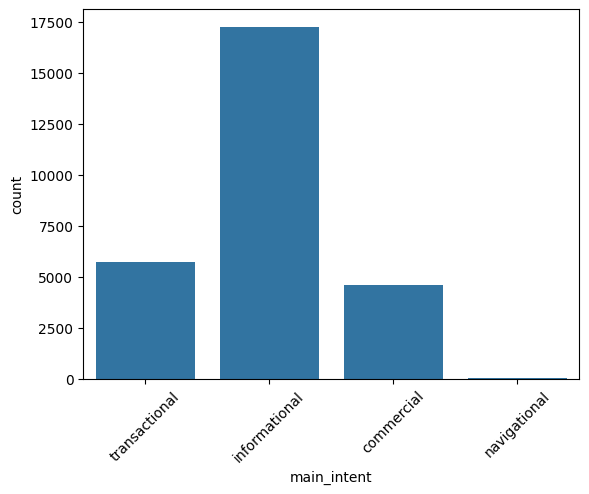

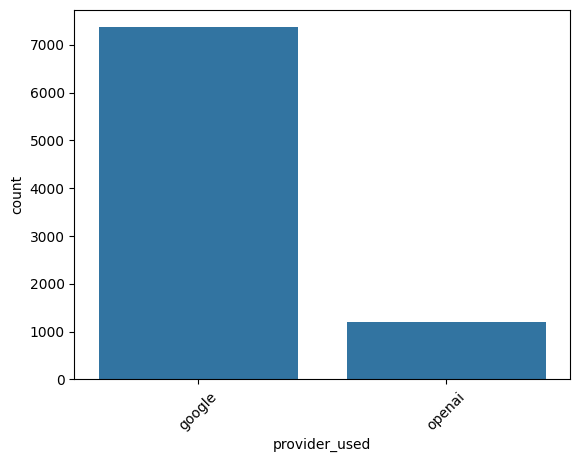

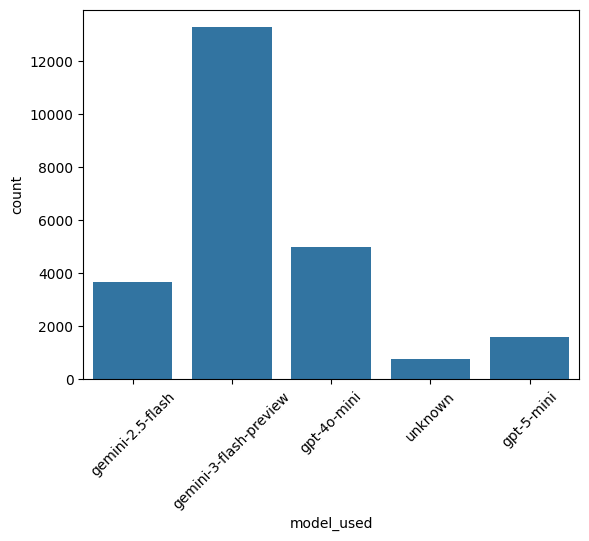

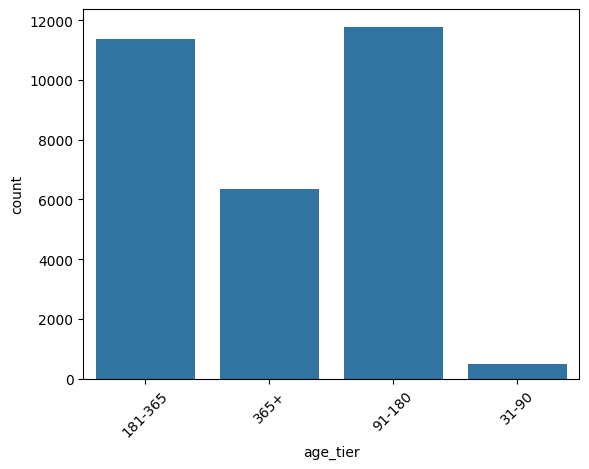

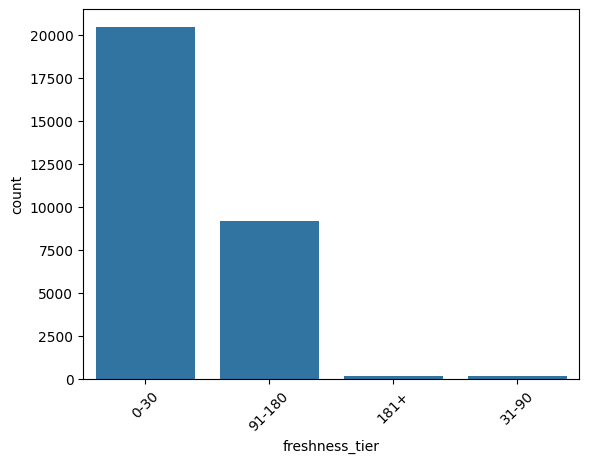

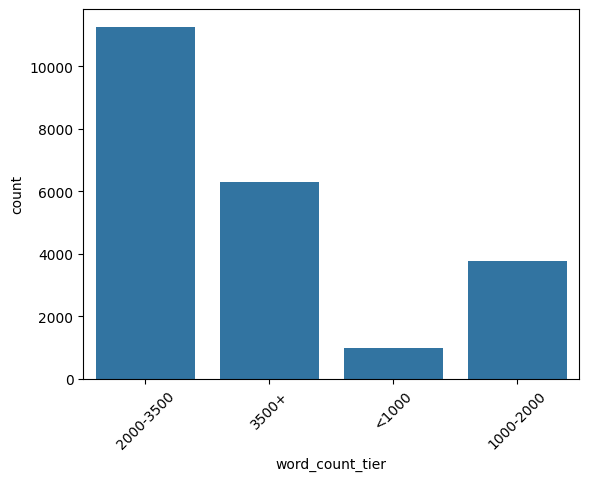

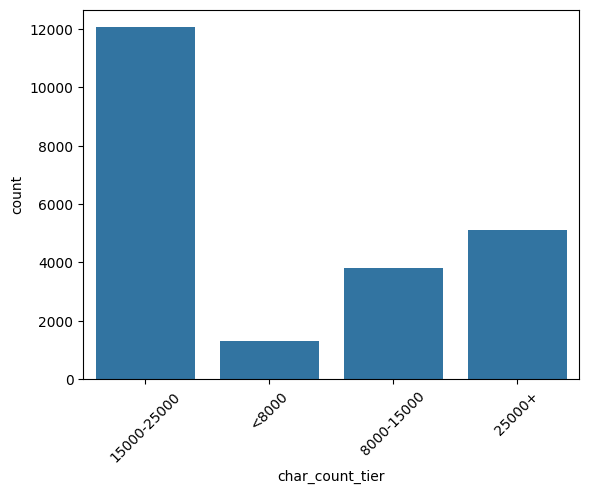

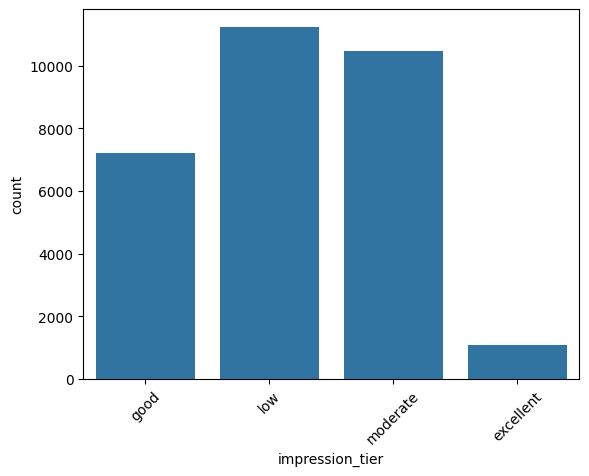

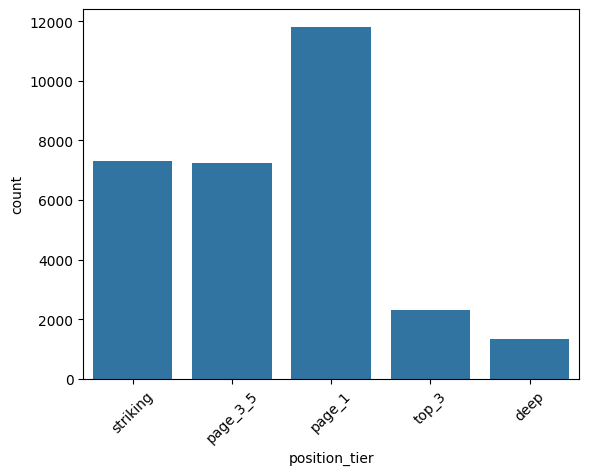

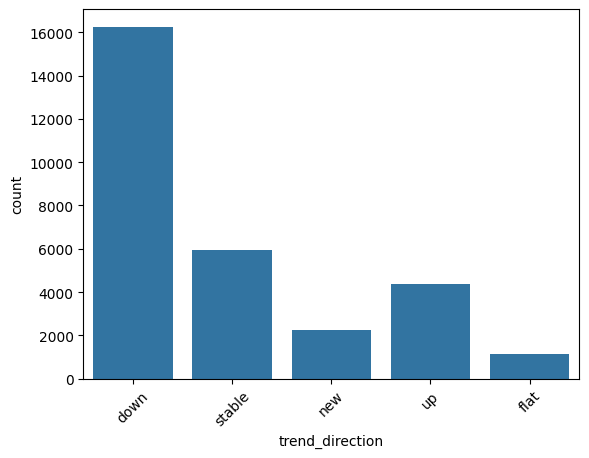

In [98]:
for col in cat:
  sns.countplot(x = col, data = df)
  plt.xticks(rotation = 45)
  plt.show()

In [7]:
# Handling missing values
df[num] = df[num].fillna(df[num].median())

In [8]:
df[cat] = df[cat].fillna("Unknown")

In [101]:
df.isnull().sum()

,0
search_volume,0
competition,0
competition_level,0
cpc,0
content_type,0
main_intent,0
word_count,0
char_count,0
provider_used,0
model_used,0


In [102]:
df[cat].head()

,competition_level,content_type,main_intent,provider_used,model_used,age_tier,freshness_tier,word_count_tier,char_count_tier,impression_tier,position_tier,trend_direction
0,HIGH,keyword article,transactional,Unknown,gemini-2.5-flash,181-365,0-30,2000-3500,15000-25000,good,striking,down
1,LOW,keyword article,informational,Unknown,gemini-3-flash-preview,365+,0-30,2000-3500,15000-25000,good,page_3_5,down
2,LOW,keyword article,informational,Unknown,gemini-2.5-flash,91-180,0-30,3500+,15000-25000,good,page_3_5,down
3,LOW,keyword article,commercial,Unknown,Unknown,365+,0-30,Unknown,Unknown,good,page_1,stable
4,LOW,keyword article,informational,Unknown,gemini-3-flash-preview,181-365,0-30,2000-3500,15000-25000,good,page_3_5,down


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
preprocessor = ColumnTransformer(transformers = [("num", StandardScaler(),num),("cat",OneHotEncoder(handle_unknown="ignore"),cat)
          ]

)

In [11]:
X_processed =preprocessor.fit_transform(df)

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [13]:
inertias = []
sil_scores = []
k_range = range(3,7)

for k in k_range:
  km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  labels = km.fit_predict(X_processed)
  inertias.append(km.inertia_)
  sil = silhouette_score(X_processed,labels, sample_size = 50000,random_state = 42)
  sil_scores.append(sil)
  print(f"k={k} inertia={km.inertia_:.0f} silhouette={sil:.4f}")


k=3 inertia=838797 silhouette=0.2772
k=4 inertia=785727 silhouette=0.1087
k=5 inertia=744734 silhouette=0.1287
k=6 inertia=708958 silhouette=0.1433


In [14]:
kmeans = KMeans(n_clusters=3,random_state = 43,n_init = 10)
df['risk_cluster'] = kmeans.fit_predict(X_processed)

In [15]:
df['risk_cluster'].value_counts()

,count
risk_cluster,
2,25916
1,3888
0,196


In [16]:
df.groupby("risk_cluster").agg({
    "trend_pct":"mean",
    "engagement_rate":"mean",
    "content_age_days":"mean"
})

,trend_pct,engagement_rate,content_age_days
risk_cluster,,,
0,146.047959,3.530561,236.301020
1,-17.556507,2.576289,237.765689
2,-7.764620,2.520721,259.078793


# Baseline Model

In [18]:
df['declining_label'] = (df["trend_direction"]== "down").astype(int)

In [63]:
df["declining_label"].value_counts(normalize=True)

,proportion
declining_label,
1,0.542067
0,0.457933


In [45]:
from sklearn.metrics import roc_auc_score,accuracy_score, classification_report,precision_score
from sklearn.model_selection import train_test_split

In [41]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["declining_label"]
)

In [42]:
baseline_pred = (test_df["trend_pct"]<0).astype(int)

In [43]:
roc_auc_score(test_df['declining_label'],baseline_pred)

np.float64(0.7545487627365357)

In [47]:
accuracy_score(test_df['declining_label'],baseline_pred)

0.7751666666666667

In [48]:
classification_report(test_df['declining_label'],baseline_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      0.51      0.67      2748\n           1       0.71      1.00      0.83      3252\n\n    accuracy                           0.78      6000\n   macro avg       0.85      0.75      0.75      6000\nweighted avg       0.84      0.78      0.76      6000\n'

In [49]:
precision_score(test_df['declining_label'],baseline_pred)

0.7068028689415344

In [114]:
# Training model using random forest classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier


In [50]:
X = df.drop(columns = ['declining_label','trend_direction','trend_pct','risk_cluster'],axis = 1)

In [51]:
num = X.select_dtypes(include="number").columns
cat = X.select_dtypes(include="object").columns

In [52]:
preprocessor = ColumnTransformer(transformers = [("num", StandardScaler(),num),("cat",OneHotEncoder(handle_unknown="ignore"),cat)
          ]

)

In [53]:
X_processed = preprocessor.fit_transform(X)

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X_processed,y,test_size = 0.2,random_state = 42, stratify = y)

In [55]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000, 76)
(6000, 76)
(24000,)
(6000,)


In [56]:
model = RandomForestClassifier(n_estimators = 100,max_depth = 6,random_state = 42)

In [57]:
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=6, random_state=42)

In [58]:
y_pred = model.predict(X_test
)

In [59]:
accuracy_score(y_test,y_pred)

0.7265

In [60]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.77      0.58      0.66      2748\n           1       0.71      0.85      0.77      3252\n\n    accuracy                           0.73      6000\n   macro avg       0.74      0.72      0.72      6000\nweighted avg       0.73      0.73      0.72      6000\n'

In [61]:
precision_score(y_test,y_pred)

0.7055371268180658

In [62]:
prob = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test,prob)

np.float64(0.8014113137856269)

In [66]:
# Result table
results = pd.DataFrame({
    "MOdel":["Baseline","Random Forest"],
    "ROC-AUC":[0.754,0.801],
    "Accuracy":[0.775,0.726],
    "Precision": [0.706,0.705]
})

results

,MOdel,ROC-AUC,Accuracy,Precision
0,Baseline,0.754,0.775,0.706
1,Random Forest,0.801,0.726,0.705


In [ ]:
#Feature Importance

In [76]:
feature_names = preprocessor.get_feature_names_out()
importance = pd.DataFrame({
    "features":feature_names,
    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    "Importance",ascending = False
)

importance.head(10)


,features,Importance
18,num__impressions_prev_30d,0.256589
13,num__days_with_impressions,0.104053
5,num__impressions_90d,0.077352
15,num__impressions_last_30d,0.072690
24,num__avg_position,0.064364
21,num__content_age_days,0.048726
51,cat__age_tier_365+,0.029349
16,num__clicks_last_30d,0.027067
17,num__sessions_last_30d,0.020900
75,cat__position_tier_top_3,0.020719


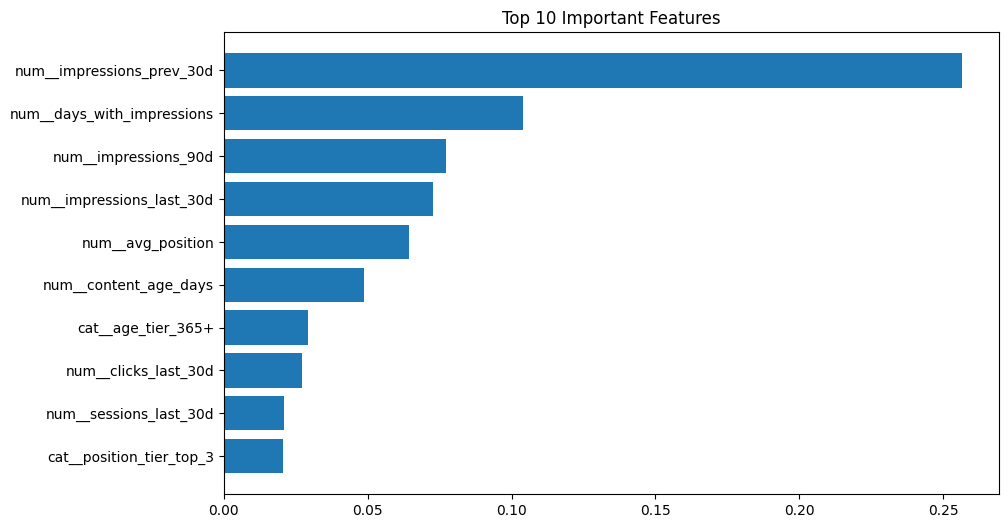

In [75]:
plt.figure(figsize=(10,6))
plt.barh(importance.head(10)["features"],
         importance.head(10)["Importance"]
         )
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

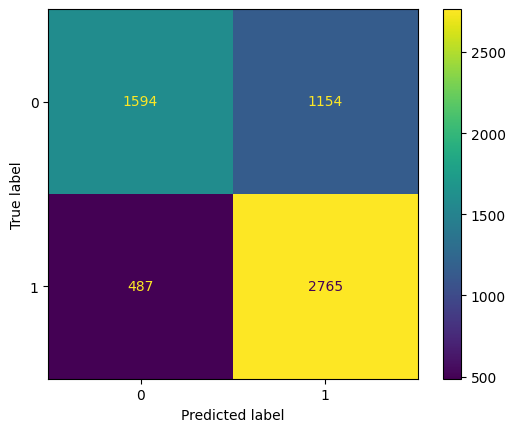

In [78]:
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
plt.show()

### Leakage check

The target variable (`declining_label`) was created from `trend_direction`.

To prevent target leakage:

- `declining_label` was removed from the feature set because it is the prediction target.
- `trend_direction` was removed because it directly defines the target.
- `trend_pct` was removed because it directly measures the observed trend and would reveal the outcome.
- `risk_cluster` was excluded from the prediction model because it was derived during exploratory clustering rather than being an original input feature.